In [1]:
import time
import numpy as np
import psi4
%matplotlib inline
import matplotlib.pyplot as plt

def diag_lps(diag, A, nel):
    Fp = psi4.core.triplet(A, diag, A, True, False, True)
    nbf = A.shape[0]
    Cp = psi4.core.Matrix(nbf, nbf)
    eigvals = psi4.core.Vector(nbf)
    Fp.diagonalize(Cp, eigvals, psi4.core.DiagonalizeOrder.Ascending)
    C = psi4.core.doublet(A, Cp, False, False)
    Cocc = psi4.core.Matrix(nbf, 1) 
    ndocc = nel // 2
    Cocc.np[:] = np.sqrt(nel) * C.np[:, ndocc-1:ndocc]
    # Cocc.np[:] = np.sqrt(nel) * C.np[:, :1]
    D = psi4.core.doublet(Cocc, Cocc, False, True) 
    return D, eigvals.np[0]

def Vpot_init(build_superfunctional, wfn, alias, vname, restricted=True):
    sup = build_superfunctional(alias, restricted)[0]
    sup.set_deriv(1)
    sup.allocate()
    Vpot = psi4.core.VBase.build(wfn.basisset(), sup, vname)
    return Vpot

def Vpot_builder(Vpot, D, V, D_half):
    D_half.copy(D)
    D_half.scale(0.5)
    Vpot.set_D([ D_half ])
    Vpot.compute_V([ V ])
    e = Vpot.quadrature_values()['FUNCTIONAL']
    return e, V

def lps_solver(maxiter, Pauli, XC, lam, mol, damp, FA, D_guess=None, DIIS=True):
    
    E_conv = 1.0e-5
    D_conv = 1.0e-5
    
    wfn = psi4.core.Wavefunction.build(mol, psi4.core.get_global_option("BASIS"))
    mints = psi4.core.MintsHelper(wfn.basisset())
    S = mints.ao_overlap()
    
    nbf = wfn.nso()
    nel = wfn.nalpha() + wfn.nbeta()

    print('Number of basis functions:   %d' % nbf)

    build_superfunctional = psi4.driver.dft.build_superfunctional
    D_half = psi4.core.Matrix(nbf, nbf)

    VPpot = Vpot_init(build_superfunctional, wfn, Pauli, "RV", restricted=True)
    VPpot.initialize()
    VP_null = psi4.core.Matrix(nbf, nbf)

    VXCpot = Vpot_init(build_superfunctional, wfn, XC, "RV", restricted=True)
    VXCpot.initialize()
    VXC_null = psi4.core.Matrix(nbf, nbf)

    vW = {
        "name": "vW",
        "x_functionals": {"LDA_X": {"alpha": 0.00}},
        "c_functionals": {"GGA_K_VW": {"alpha": 1.00}}
    }
    VvWpot = Vpot_init(build_superfunctional, wfn, vW, "RV", restricted=True)
    VvWpot.initialize()
    VvW_null = psi4.core.Matrix(nbf, nbf)

    V = mints.ao_potential()
    T = mints.ao_kinetic()
    H = T.clone()
    H.add(V)
    I = np.asarray(mints.ao_eri())
    A = mints.ao_overlap()
    A.power(-0.5, 1.e-14)
    F = psi4.core.Matrix(nbf, nbf)
    J = psi4.core.Matrix(nbf, nbf)
    VG = psi4.core.Matrix(nbf, nbf)
    D_diff = psi4.core.Matrix(nbf, nbf)
    
    if D_guess is not None:
        D = D_guess.clone()
        mu = 0
    else:
        D, mu = diag_lps(H, A, nel)

    Enuc = mol.nuclear_repulsion_energy()
    Eold = 0.0
    
    print('\nStarting SCF iterations:')
    t = time.time()
    conv_list = []

    if DIIS:
        diis_obj = psi4.p4util.solvers.DIIS(max_vec=6, removal_policy="oldest")
   
    print("\n    Iter               Energy         ChemPot       Delta E         dRMS\n")
    for SCF_ITER in range(1, maxiter + 1):
    
        D_old = D
        
        J_np = np.einsum('pqrs,rs->pq', I, D.np, optimize=True)
        J.np[:] = J_np
        F.copy(H)
        F.axpy(1.0, J)
        if FA[0]:
            if nel == 0:
                F.axpy(0.0, J)
            else: 
                F.axpy(-FA[1]/nel, J)

        pau_e, VP = Vpot_builder(VPpot, D, VP_null, D_half)
        xc_e, VXC = Vpot_builder(VXCpot, D, VXC_null, D_half)
        vw_e, VvW = Vpot_builder(VvWpot, D, VvW_null, D_half)
        g_e = pau_e + xc_e + ( lam - 1.0 ) * vw_e 

        VG.copy(VP)
        VG.axpy(1.0, VXC)
        VG.axpy((lam - 1.0), VvW)
        F.axpy(1.0, VG)

        if DIIS:
            diis_e = psi4.core.triplet(F, D, S, False, False, False)
            diis_e.subtract(psi4.core.triplet(S, D, F, False, False, False))
            diis_e = psi4.core.triplet(A, diis_e, A, False, False, False)
        
            diis_obj.add(F, diis_e)
            dRMS = diis_e.rms()

        SCF_E = H.vector_dot(D)
        SCF_E += 0.5 * J.vector_dot(D)
        if FA[0]:
            SCF_E += 0.5 * J.vector_dot(D) * ( - FA[1] / nel )
        SCF_E += g_e
        SCF_E += Enuc

        conv_list.append(np.log10(abs(SCF_E - Eold)))

        if DIIS:
            print('SCF Iter%3d: % 18.8f   % 1.5E   % 1.5E   % 1.5E'
                % (SCF_ITER, SCF_E, mu, (SCF_E - Eold), dRMS))
            
            if (abs(SCF_E - Eold) < E_conv and dRMS < D_conv):
                break
            
            Eold = SCF_E
            F = diis_obj.extrapolate()

        D, mu = diag_lps(F, A, nel)

        if not DIIS:
            D_diff.copy(D)
            D_diff.subtract(D_old)
            dRMS = D_diff.rms()
            print('SCF Iter%3d: % 18.8f   % 1.5E   % 1.5E   % 1.5E'
                % (SCF_ITER, SCF_E, mu, (SCF_E - Eold), dRMS))
            
            if (abs(SCF_E - Eold) < E_conv and dRMS < D_conv):
                break

            Eold = SCF_E
        
        if (dRMS > damp[2]):
            current_damp = damp[0]
        else:
            current_damp = damp[1]
        D.scale(1.0 - current_damp)
        D.axpy(current_damp, D_old)
        
        if SCF_ITER == maxiter:
            SCF_D = D
            print("\nWARNING ! SCF did not converge. The final values are printed")
            return SCF_E, SCF_D, SCF_ITER
    
    SCF_D = D
    
    print('\nTotal time for SCF iterations: %.3f seconds ' % (time.time() - t))

    return SCF_E, SCF_D, SCF_ITER, conv_list

In [9]:
psi4.core.clean_options()
psi4.core.clean()
psi4.core.set_output_file('output.dat', False)

mol = psi4.geometry("""
units bohr
0 1
Be
symmetry c1
""")
psi4.set_options({'basis': 'UGBS_S', 
                 'DFT_SPHERICAL_POINTS': 6,
                  'DFT_RADIAL_POINTS': 1000})

Pauli = {
    "name": "Pauli",
    "x_functionals": {"LDA_X": {"alpha": 0.00}},
    "c_functionals": {"LDA_K_TF": {"alpha": 1.00}}
}
XC = {
    "name": "XC",
    "x_functionals": {"LDA_X": {"alpha": 1.00}},
    "c_functionals": {"LDA_C_VWN": {"alpha": 0.00}}
}

## Damping factor before cutoff, after cutoff, the cutoff.
damp = [0.0, 0.0, 0.0001]
## Calculate Fermi–Amaldi? Scaling factor.
FA = [False, 1.0]

SCF_E, D, lda_SCF_ITER, lda_conv_list = lps_solver(5000, Pauli, XC, 0.2, mol, damp, FA, D_guess=None, DIIS=True)
print('\nFinal SCF energy: %.4f Hartree' % SCF_E)

Number of basis functions:   31

Starting SCF iterations:

    Iter               Energy         ChemPot       Delta E         dRMS

SCF Iter  1:        -7.89609250   -8.00000E+00   -7.89609E+00    7.39083E-01
SCF Iter  2:        -5.07897030   -1.13058E+01    2.81712E+00    1.59669E-01
SCF Iter  3:        -5.13471315   -2.14554E+01   -5.57428E-02    1.44134E-01
SCF Iter  4:       429.31710651   -1.06016E+04    4.34452E+02    1.92463E+01
SCF Iter  5:       421.30298206   -1.13956E+04   -8.01412E+00    1.85446E+01
SCF Iter  6:         7.88071615   -1.00342E+04   -4.13422E+02    4.68605E-01
SCF Iter  7:         7.90128877   -6.02040E+03    2.05726E-02    4.68084E-01
SCF Iter  8:       294.87032778   -7.23183E+04    2.86969E+02    4.27795E+01
SCF Iter  9:       209.12501593   -2.42384E+05   -8.57453E+01    5.58378E+01
SCF Iter 10:        85.88975734   -1.52077E+06   -1.23235E+02    4.31457E+01
SCF Iter 11:        89.53927147   -1.52476E+06    3.64951E+00    6.01109E+01
SCF Iter 12:        

KeyboardInterrupt: 

In [3]:
def prim_gauss(a, d, r):
    g = ( 2 * a / np.pi ) ** ( 3 / 4 ) * np.exp( - a * r ** 2 )
    return d * g

lps_a_list = [
    11387194.5850786, 5815282.94190191, 2969784.65079439, 1516627.98873367,
    774520.959152738, 395537.152566831, 201995.358823884, 103156.238855453,
    52680.4659115021, 26903.1860742975, 13739.0854166734, 7016.36109438299,
    3583.15866840945, 1829.86962476550, 934.489134729210, 477.230689612032,
    243.715119463182, 124.461944187287, 63.5609952513411, 32.4597220758638,
    16.5767315800501, 8.46550778330153, 4.32321786011102, 2.20780762884063,
    1.12749685157938, 0.575797063890464, 0.294051604951678, 0.150168091845475,
    7.668876968794860e-002, 3.916389509898707e-002, 2.000046011385546e-002
]

def rad_distrib(D, a_list, r):
    res = 0
    for i in range(0, len(a_list)):
        for j in range(0, len(a_list)):
            res += D[i,j] * prim_gauss(a_list[i], 1, r) * prim_gauss(a_list[j], 1, r)
    return res

In [4]:
r = np.arange(0.0, 10.01, 0.01)
density = rad_distrib(D.np, lps_a_list, r)

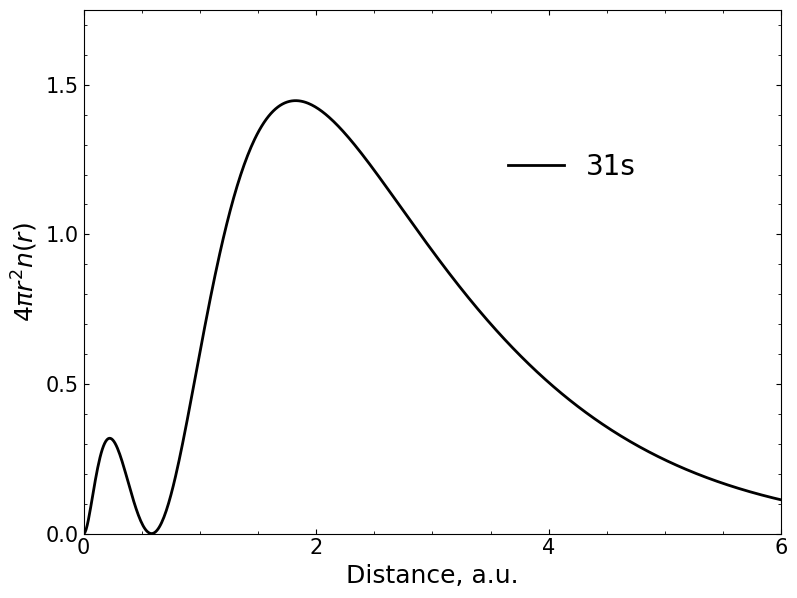

In [5]:
fig, ax = plt.subplots(figsize=(9, 6.8))
ax.plot(r, 4 * np.pi * r **2 * density, label='31s', color='black', linestyle='-', linewidth=2)
ax.legend(loc='center', bbox_to_anchor=(0.70, 0.70), fontsize=20, frameon=False)
ax.tick_params(axis='both', direction='in', top=True, right=True)
ax.minorticks_on()
ax.tick_params(which='minor', axis='both', direction='in', top=True, right=True)
ax.set_xlabel("Distance, a.u.", fontsize=18)
ax.set_ylabel("4$\\pi r^2 n(r)$", fontsize=18)
ax.axis([0.0, 6, 0, 1.75])
ax.set_xticks(np.arange(0.0, 8.0, 2.0))
ax.tick_params(axis='x', labelsize=15)
ax.set_yticks(np.arange(0.0, 2.0, 0.50))
ax.tick_params(axis='y', labelsize=15)

In [19]:
psi4.core.set_output_file('output.dat', False)

XC = {
    "name": "XC",
    "x_functionals": {"GGA_X_PBE": {"alpha": 1.00}},
    "c_functionals": {"LDA_C_VWN": {"alpha": 0.00}}
}

## Damping factor before cutoff, after cutoff, the cutoff.
damp = [0.9, 0.9, 0.0001]
## Calculate Fermi–Amaldi? Scaling factor.
FA = [False, 1.0]

SCF_E, D, pbe_SCF_ITER, pbe_conv_list = lps_solver(5000, Pauli, XC, 0.166666, mol, damp, FA, D_guess=None, DIIS=True)
print('\nFinal SCF energy: %.4f Hartree' % SCF_E)

Number of basis functions:   31

Starting SCF iterations:

    Iter               Energy         ChemPot       Delta E         dRMS

SCF Iter  1:        -2.38541050   -2.00000E+00   -2.38541E+00    1.93315E-01
SCF Iter  2:        -2.56304498    6.84767E-01   -1.77634E-01    1.72632E-01
SCF Iter  3:        -2.65557671    2.88808E-03   -9.25317E-02    1.56018E-01
SCF Iter  4:        -1.71000660   -3.09302E+01    9.45570E-01    2.40920E-01
SCF Iter  5:        -0.75823508   -3.09934E+01    9.51772E-01    2.58706E-01
SCF Iter  6:        -0.22485720   -1.50418E+01    5.33378E-01    2.73450E-01
SCF Iter  7:         0.31412084   -1.49447E+01    5.38978E-01    2.97683E-01
SCF Iter  8:        -0.37167301   -1.51666E-02   -6.85794E-01    2.54566E-01
SCF Iter  9:        -0.88018432   -1.44903E-02   -5.08511E-01    2.20466E-01
SCF Iter 10:        -1.10680992   -8.24417E+01   -2.26626E-01    1.95471E-01
SCF Iter 11:        -1.28768735   -8.36452E+01   -1.80877E-01    1.79803E-01
SCF Iter 12:        

In [20]:
XC = {
    "name": "XC",
    "x_functionals": {"LDA_X": {"alpha": 0.00}},
    "c_functionals": {"LDA_C_VWN": {"alpha": 0.00}}
}

## Damping factor before cutoff, after cutoff, the cutoff.
damp = [0.9, 0.9, 0.0001]
## Calculate Fermi–Amaldi? Scaling factor.
FA = [True, 1.0]

SCF_E, D, fa_SCF_ITER, fa_conv_list = lps_solver(5000, Pauli, XC, 0.166666, mol, damp, FA, D_guess=None, DIIS=True)
print('\nFinal SCF energy: %.4f Hartree' % SCF_E)

Number of basis functions:   31

Starting SCF iterations:

    Iter               Energy         ChemPot       Delta E         dRMS

SCF Iter  1:        -2.41164823   -2.00000E+00   -2.41165E+00    1.87187E-01
SCF Iter  2:        -2.46869111    3.72080E-01   -5.70429E-02    1.75552E-01
SCF Iter  3:        -2.54517325    8.10249E-02   -7.64821E-02    1.57608E-01
SCF Iter  4:        -2.46488889   -2.01002E+00    8.02844E-02    1.76640E-01
SCF Iter  5:        -2.38713723   -1.94090E+00    7.77517E-02    1.85981E-01
SCF Iter  6:        -2.47140695   -4.18968E-01   -8.42697E-02    1.66805E-01
SCF Iter  7:        -2.49650173   -7.97905E-01   -2.50948E-02    1.50957E-01
SCF Iter  8:        -2.48579554   -1.37669E+00    1.07062E-02    1.56358E-01
SCF Iter  9:        -2.45468440   -1.64747E+00    3.11111E-02    1.63818E-01
SCF Iter 10:        -2.35526880   -2.24068E+00    9.94156E-02    1.77088E-01
SCF Iter 11:        -2.16459435   -3.23622E+00    1.90674E-01    1.96172E-01
SCF Iter 12:        

ValueError: x and y must have same first dimension, but have shapes (238,) and (185,)

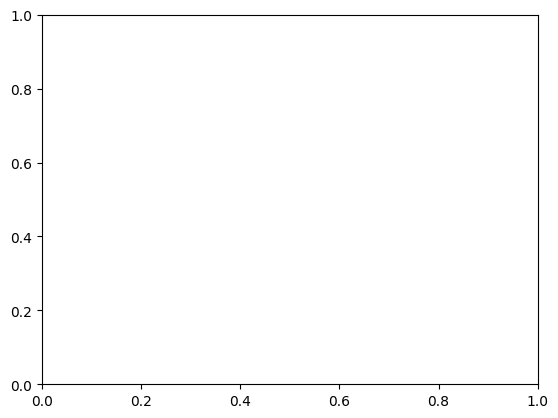

In [ ]:
dist = np.linspace(1, 1000, 1000)
plt.plot(dist, lda, color = 'red', linestyle='-', label='LDA')
plt.plot(dist, pbe, color = 'blue', linestyle='-', label='PBE')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.7)
plt.legend()